### Catboost base

CatBoost es probablemente la herramienta más potente para este dataset porque está diseñado específicamente para manejar variables categóricas sin necesidad de pre-procesamiento manual (como el One-Hot o el Frequency Encoding que se realizó para Random Forest).

Para este modelo base, se identificaron cuáles son las columnas categóricas y se las ingresó al modelo. CatBoost se encarga de los algoritmos de cuantización y combinación de categorías internamente, lo que suele reducir drásticamente el overfitting.

1_Carga del dataset train

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from catboost import CatBoostClassifier

# 1. Cargar los datos
df = pd.read_csv('C:/Users/GWF-SerIA/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train/train.csv')
# Mostrar el dataset
df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


Eliminación de variables e identificacón de variables categóricas

In [3]:
import pandas as pd
import numpy as np

# 1. Eliminar variables de identidad y texto (Leakage y ruido)
columnas_a_eliminar = ['PetID', 'RescuerID', 'Name', 'Description']
# Usamos errors='ignore' por si la celda se corre más de una vez
df = df.drop(columns=columnas_a_eliminar, errors='ignore') 

# --- TRANSFORMACIONES PARA ALTA CARDINALIDAD Y ROBUSTEZ ---

# A. Razas (Breed1, Breed2)
# 1. Crear la característica binaria 'is_mixed' (Mestizo). 
# En el dataset de Petfinder, Breed2 == 0 suele indicar raza pura.
df['is_mixed'] = (df['Breed2'] != 0).astype(int)

# 2. Agrupar razas raras (Breed1 y Breed2) para evitar sobreajuste.
# Definimos un umbral de frecuencia. Todo lo que aparezca menos de N veces va a "Otro".
umbral_raza = 30  # Podés ajustar este hiperparámetro
freq_breed1 = df['Breed1'].value_counts()
razas_raras_1 = freq_breed1[freq_breed1 < umbral_raza].index
df['Breed1'] = df['Breed1'].replace(razas_raras_1, 'Rare_Breed')

freq_breed2 = df['Breed2'].value_counts()
razas_raras_2 = freq_breed2[freq_breed2 < umbral_raza].index
df['Breed2'] = df['Breed2'].replace(razas_raras_2, 'Rare_Breed')

# B. Estados Geográficos (State)
# Agrupar estados con muy pocos registros para mantener la estabilidad del modelo
umbral_estado = 50
freq_estado = df['State'].value_counts()
estados_raros = freq_estado[freq_estado < umbral_estado].index
df['State'] = df['State'].replace(estados_raros, 'Other_State')

# C. Colores (Feature Engineering para evitar cruces complejos)
# En lugar de cruzar Color1, Color2 y Color3 y arriesgar alta cardinalidad combinada,
# podemos contar la cantidad de colores que tiene el animal, lo cual es un buen proxy.
# (Asumiendo que 0 significa "sin color" en esa ranura)
df['num_colors'] = (df[['Color1', 'Color2', 'Color3']] != 0).sum(axis=1)

#  Eliminamos los colores secundarios para reducir ruido y evitar combinaciones raras
df = df.drop(columns=['Color2', 'Color3'])

# ----------------------------------------------------------

# 3. Identificar variables categóricas
cat_features = [
    'Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 
     'State', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
    'is_mixed' # Agregamos la nueva variable categórica
]

# PASO CLAVE PARA CATBOOST: 
# PetFinder suele traer estas variables como enteros (IDs). 
# Para que CatBoost no las interprete como variables numéricas continuas por error, 
# forzamos explícitamente el tipo de dato a string.
for col in cat_features:
    df[col] = df[col].astype(str)

# Mostrar el dataset resultante
df.head()

,Type,Age,Breed1,Breed2,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed,is_mixed,num_colors
0,2,3,299,0,1,1,1,1,2,2,2,1,1,100,41326,0,1.0,2,0,2
1,2,1,265,0,1,1,2,2,3,3,3,1,1,0,41401,0,2.0,0,0,2
2,1,1,307,0,1,2,2,2,1,1,2,1,1,0,41326,0,7.0,3,0,2
3,1,4,307,0,2,1,2,1,1,1,2,1,1,150,41401,0,8.0,2,0,2
4,1,1,307,0,1,1,2,1,2,2,2,1,1,0,41326,0,3.0,2,0,1


Separar en train y test de manera estratificada.

In [4]:
# 4. Definir Target (y) y Features (X)
y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# 5. Separar en train y test (66% / 34%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.34, 
    random_state=42, 
    stratify=y
)
print(f"Datos cargados: {X_train.shape[0]} filas para entrenar y {X_test.shape[0]} para test.")

Datos cargados: 9895 filas para entrenar y 5098 para test.


#### Prueba de GPU

In [8]:

# Prueba drivers CUDA
from catboost import CatBoostClassifier

# Intentamos crear un modelo mínimo en GPU
try:
    model = CatBoostClassifier(task_type="GPU", iterations=1)
    print("¡GPU detectada y lista!")
except:
    print("No se detectó GPU compatible o faltan drivers CUDA.")

¡GPU detectada y lista!


#### Entrenamiento y test del modelo

In [12]:
# 6. Configurar el modelo CatBoost
# Usamos parámetros conservadores para un baseline sólido
cb = CatBoostClassifier(
    iterations=500,          # Subimos iteraciones pero usamos Early Stopping
    learning_rate=0.05,       # Una tasa baja es buena para la generalización
    depth=5,                  # Bajamos un poco la profundidad para mayor simpleza
    l2_leaf_reg=10,           # Aumentamos la regularización L2 (de 3 a 10)
    
    # --- NUEVOS PARÁMETROS ANTI-OVERFITTING ---
    # --- AJUSTES PARA GPU ---
    # bagging_temperature=1,    # Agrega aleatoriedad en la selección de las muestras
    bootstrap_type='Bernoulli', # Reemplaza el comportamiento de bagging en GPU
    subsample=0.8,              # Selecciona el 80% de las filas (reemplaza rsm en efectividad)
    random_strength=1,        # Agrega ruido a las puntuaciones para evitar splits deterministas
    # rsm=0.8,                  # (Random Subspace Method): Selecciona solo el 80% de las columnas por árbol
    
    loss_function='MultiClass',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100, # SE DETIENE si en 100 vueltas no mejora la métrica de validación
    task_type="GPU",       # <--- Esto activa la GPU
    devices='0'
)

# 7. Validación Cruzada con StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kappa_scores = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Entrenar pasando el parámetro cat_features
    cb.fit(X_fold_train, y_fold_train, cat_features=cat_features)
    
    preds = cb.predict(X_fold_val)
    kappa = cohen_kappa_score(y_fold_val, preds, weights='quadratic')
    kappa_scores.append(kappa)

print(f"CatBoost QWK en CV (Media): {np.mean(kappa_scores):.4f}")

# 8. Evaluación final en Test
cb.fit(X_train, y_train,
       eval_set=(X_train, y_train),  # Usamos el mismo train para evaluación interna (puede ser un fold de validación)
       cat_features=cat_features,
       use_best_model=True  # Al terminar, se queda con el árbol que mejor Kappa/Loss dio en val cat_features=cat_features)
       )
test_preds = cb.predict(X_test)
test_kappa = cohen_kappa_score(y_test, test_preds, weights='quadratic')

print(f"CatBoost QWK en Test: {test_kappa:.4f}")

0:	learn: 1.5941771	total: 10.6ms	remaining: 5.28s
100:	learn: 1.3175348	total: 1.06s	remaining: 4.19s
200:	learn: 1.2940181	total: 2.09s	remaining: 3.11s
300:	learn: 1.2812664	total: 3.22s	remaining: 2.13s
400:	learn: 1.2687677	total: 4.39s	remaining: 1.08s
499:	learn: 1.2596416	total: 5.51s	remaining: 0us
0:	learn: 1.5936448	total: 11.4ms	remaining: 5.68s
100:	learn: 1.3220744	total: 1.04s	remaining: 4.1s
200:	learn: 1.3030992	total: 1.99s	remaining: 2.97s
300:	learn: 1.2877209	total: 3.06s	remaining: 2.02s
400:	learn: 1.2693711	total: 4.15s	remaining: 1.02s
499:	learn: 1.2589387	total: 5.24s	remaining: 0us
0:	learn: 1.5938597	total: 11.9ms	remaining: 5.94s
100:	learn: 1.3218475	total: 1.04s	remaining: 4.12s
200:	learn: 1.2957651	total: 2.06s	remaining: 3.07s
300:	learn: 1.2825827	total: 3.17s	remaining: 2.1s
400:	learn: 1.2735019	total: 4.29s	remaining: 1.06s
499:	learn: 1.2664441	total: 5.39s	remaining: 0us
0:	learn: 1.5940594	total: 12.5ms	remaining: 6.24s
100:	learn: 1.3250515	to

#### Importancia de variables

C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_16072\3662960797.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


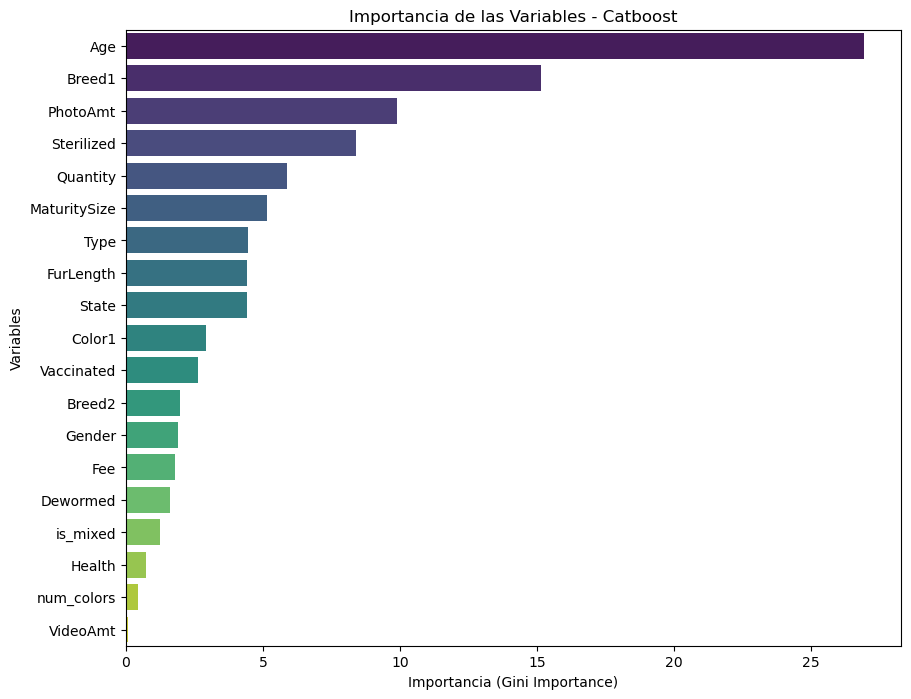

Top 5 variables más influyentes:
       Feature  Importance
1          Age   26.932742
2       Breed1   15.124571
16    PhotoAmt    9.902516
10  Sterilized    8.409320
12    Quantity    5.865995


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener la importancia de las variables del modelo final
importances = cb.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame para facilitar el gráfico
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables - Catboost')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Variables')
plt.show()

# 4. Mostrar las top 5 para análisis rápido
print("Top 5 variables más influyentes:")
print(feature_importance_df.head(5))